**Step-0 Loading Dataset**


In [1]:
from google.colab import files
uploaded = files.upload()

Saving AAPL.csv to AAPL.csv


**Step -1 Verify dataset**

In [2]:
import pandas as pd

df = pd.read_csv("AAPL.csv")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


# Step 2: Problem Definition

The goal of this project is to predict whether the stock price will increase or decrease on the next day.

Stock datasets normally contain historical prices such as Open, High, Low, Close, and Volume.
However, machine learning models require a target variable that represents the correct answer.

To create the target variable:
- If the next day's closing price is greater than today's closing price → Target = 1
- If the next day's closing price is less than or equal to today's closing price → Target = 0

This converts the problem into a **binary classification problem**, where the model predicts whether the price will go **UP (1)** or **DOWN (0)**.

In [3]:
# Step 2: Create Target Variable

# Target = 1 if next day's close price is higher than today's close price
# Target = 0 if next day's close price is lower

df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# Show first few rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Target
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400,0
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,0
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,1
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,1
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,1


In [4]:
# Verify the target column

df[["Date","Close","Target"]].head(10)

,Date,Close,Target
0,1980-12-12,0.513393,0
1,1980-12-15,0.486607,0
2,1980-12-16,0.450893,1
3,1980-12-17,0.462054,1
4,1980-12-18,0.475446,1
5,1980-12-19,0.504464,1
6,1980-12-22,0.529018,1
7,1980-12-23,0.551339,1
8,1980-12-24,0.580357,1
9,1980-12-26,0.633929,1


# Step 3: Data Preprocessing

Raw datasets often contain missing values, inconsistent formats, or unnecessary columns.
Data preprocessing improves data quality before training a machine learning model.

In this step we perform the following tasks:

1. Check the structure of the dataset
2. Identify missing values
3. Remove rows with missing values
4. Prepare the dataset for machine learning

Preprocessing ensures that the model receives clean and reliable data.

In [5]:
# Check dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
 7   Target     9909 non-null   int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 619.4+ KB


In [6]:
# Check for missing values in each column

df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Target,0


In [7]:
# Remove rows with missing values

df = df.dropna()

# Check dataset size after cleaning
df.shape

(9909, 8)

In [8]:
# View cleaned dataset

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Target
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400,0
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,0
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,1
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,1
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,1


# Step 4: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the structure and patterns in the dataset before building a machine learning model.

In this step we perform the following analysis:

1. Visualize stock price trends over time
2. Analyze the distribution of trading volume
3. Examine correlation between different features

EDA helps identify patterns and relationships that may influence stock price movements.

In [9]:
# Import libraries for visualization

import matplotlib.pyplot as plt
import seaborn as sns

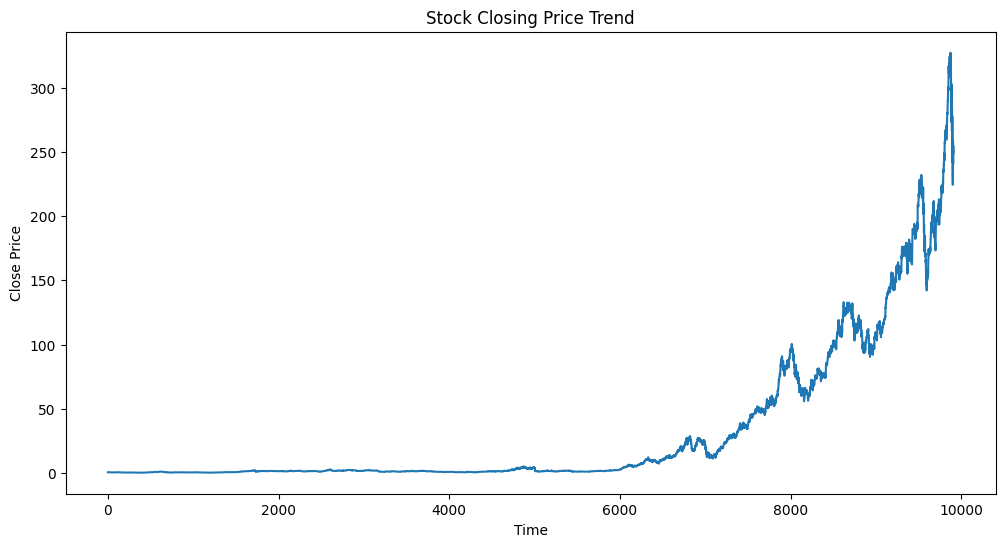

In [10]:
# Plot stock closing price over time

plt.figure(figsize=(12,6))

plt.plot(df["Close"])

plt.title("Stock Closing Price Trend")
plt.xlabel("Time")
plt.ylabel("Close Price")

plt.show()

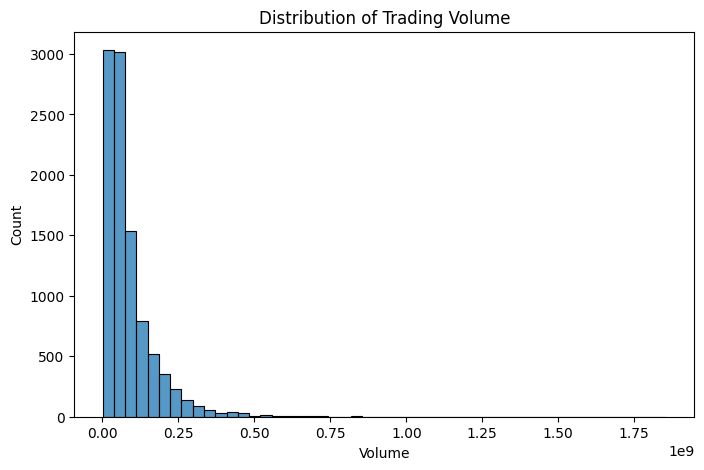

In [11]:
# Distribution of trading volume

plt.figure(figsize=(8,5))

sns.histplot(df["Volume"], bins=50)

plt.title("Distribution of Trading Volume")

plt.show()

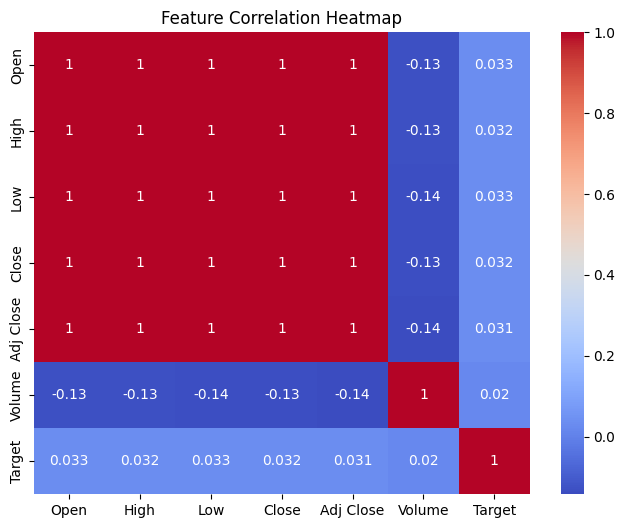

In [13]:
# Correlation between features

plt.figure(figsize=(8,6))

sns.heatmap(df.drop("Date", axis=1).corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

# Step 5: Feature Engineering

Feature engineering is the process of creating new useful features from existing data.

In financial time-series prediction, moving averages and price changes help capture trends and market momentum.

In this step we create new features:

1. Moving Average (10 days) → MA10
2. Moving Average (50 days) → MA50
3. Price Change → Difference between closing and opening price

These features help the machine learning model better understand stock price behavior.


In [14]:
# Create Moving Average features

df["MA10"] = df["Close"].rolling(window=10).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

# Create price change feature

df["Price_Change"] = df["Close"] - df["Open"]

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Target,MA10,MA50,Price_Change
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400,0,NaN,NaN,0.000000
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,0,NaN,NaN,-0.002232
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,1,NaN,NaN,-0.002232
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,1,NaN,NaN,0.000000
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,1,NaN,NaN,0.000000


In [15]:
# Remove rows with missing values created by moving averages

df = df.dropna()

# Check new dataset size
df.shape

(9860, 11)

In [16]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Target,MA10,MA50,Price_Change
49,1981-02-24,0.428571,0.428571,0.424107,0.424107,0.336037,4244800,1,0.458705,0.530312,-0.004464
50,1981-02-25,0.450893,0.453125,0.450893,0.450893,0.357260,4872000,1,0.455134,0.529062,0.000000
51,1981-02-26,0.457589,0.459821,0.457589,0.457589,0.362566,2710400,1,0.453795,0.528482,0.000000
52,1981-02-27,0.473214,0.477679,0.473214,0.473214,0.374946,3690400,1,0.454464,0.528929,0.000000
53,1981-03-02,0.475446,0.477679,0.475446,0.475446,0.376715,2940000,0,0.456473,0.529196,0.000000


# Step 6: Train-Test Split

In machine learning, the dataset must be divided into two parts:

1. Training Data – used to train the machine learning model.
2. Testing Data – used to evaluate how well the model performs on unseen data.

This prevents the model from simply memorizing the dataset.

In this project we split the dataset as:

80% → Training data  
20% → Testing data

In [17]:
# Select input features

features = ["Open","High","Low","Close","Volume","MA10","MA50","Price_Change"]

X = df[features]

# Target variable

y = df["Target"]

X.head()

,Open,High,Low,Close,Volume,MA10,MA50,Price_Change
49,0.428571,0.428571,0.424107,0.424107,4244800,0.458705,0.530312,-0.004464
50,0.450893,0.453125,0.450893,0.450893,4872000,0.455134,0.529062,0.000000
51,0.457589,0.459821,0.457589,0.457589,2710400,0.453795,0.528482,0.000000
52,0.473214,0.477679,0.473214,0.473214,3690400,0.454464,0.528929,0.000000
53,0.475446,0.477679,0.475446,0.475446,2940000,0.456473,0.529196,0.000000


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (7888, 8)
Testing data size: (1972, 8)


# Step 7: Model Selection

The next step is selecting a suitable machine learning algorithm.

Since our task is to predict whether the stock price will go up or down, this is a classification problem.

Several algorithms can be used for classification such as:
- Logistic Regression
- Support Vector Machines
- Random Forest

In this project we use Random Forest Classifier because it performs well on tabular financial datasets and can capture complex relationships between features.

In [20]:
# Import the Random Forest model

from sklearn.ensemble import RandomForestClassifier

# Create the model

model = RandomForestClassifier()

# Train the model using training data

model.fit(X_train, y_train)

RandomForestClassifier()

In [21]:
print("Model training completed")

Model training completed


# Step 9: Model Evaluation

After training the machine learning model, it is important to evaluate how well it performs on unseen data.

The evaluation is done using the testing dataset that was not used during training.

In this step we measure the performance of the model using evaluation metrics such as:

- Accuracy
- Confusion Matrix
- Classification Report

These metrics help determine how well the model predicts stock price movement.

In [22]:
# Predict stock movement on test data

y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 1, 1, 0, 0, 1, 1, 1])

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5116632860040567


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[528 461]
 [502 481]]


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.53      0.52       989
           1       0.51      0.49      0.50       983

    accuracy                           0.51      1972
   macro avg       0.51      0.51      0.51      1972
weighted avg       0.51      0.51      0.51      1972



# Step 10: Hyperparameter Tuning

Hyperparameter tuning is used to improve the performance of a machine learning model.

Machine learning algorithms have parameters that control how the model learns patterns from data.
By adjusting these parameters, we can improve prediction accuracy.

In this project we use GridSearchCV to test different combinations of parameters for the Random Forest model.

The parameters tested include:
- n_estimators (number of trees in the forest)
- max_depth (maximum depth of the trees)

Grid Search finds the best combination of parameters that gives the highest model performance.

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10]
}

# Grid Search model
grid_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring="accuracy"
)

# Train Grid Search
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10], 'n_estimators': [100, 200]},
             scoring='accuracy')

In [27]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


In [28]:
best_model = grid_search.best_estimator_

print("Optimized model ready")

Optimized model ready


# Step 11: Model Deployment

After training and optimizing the machine learning model, the next step is to save the model so it can be used later in real-world applications.

Saving the model allows us to load it later without retraining.

In this project we save the trained Random Forest model using the Joblib library.

In [29]:
# Install joblib library

!pip install joblib

In [30]:
import joblib

# Save the optimized model

joblib.dump(best_model, "stock_price_model.pkl")

print("Model saved successfully")

Model saved successfully


In [31]:
import os

os.listdir()

['.config', 'AAPL.csv', 'stock_price_model.pkl', 'sample_data']

# Step 12: User Interface for Prediction

To make the model interactive, we create a simple prediction interface.

This interface allows a user to input stock market values such as:

- Open Price
- High Price
- Low Price
- Close Price
- Volume
- Moving Average (MA10)
- Moving Average (MA50)
- Price Change

The trained model then predicts whether the stock price will go UP or DOWN.

In [32]:
# Example input values for prediction

sample_data = [[
    0.45,   # Open
    0.47,   # High
    0.44,   # Low
    0.46,   # Close
    3000000, # Volume
    0.45,   # MA10
    0.46,   # MA50
    0.01    # Price Change
]]

In [33]:
# Load the saved model

loaded_model = joblib.load("stock_price_model.pkl")

prediction = loaded_model.predict(sample_data)

if prediction[0] == 1:
    print("Prediction: Stock Price will go UP")
else:
    print("Prediction: Stock Price will go DOWN")

Prediction: Stock Price will go DOWN


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [34]:
from google.colab import files
files.download("stock_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>